# K-Medoids Clustering

K-Medoids is an unsupervised clustering algorithm similar to K-Means, but instead of using the mean as the cluster center, it selects an **actual data point (medoid)** as the cluster center.

This makes the algorithm more robust to **noise and outliers**.

---

## Objective Function

The goal of K-Medoids is to minimize the total dissimilarity between data points and their medoid.

$$
J = \sum_{i=1}^{k} \sum_{x \in C_i} d(x, m_i)
$$

Where:

- \(k\) = number of clusters
- \(C_i\) = cluster i
- \(x\) = data point
- \(m_i\) = medoid of cluster
- \(d(x,m_i)\) = distance between point and medoid

---

## Distance Metric

Usually Euclidean distance is used:

$$
d(x, m) = \sqrt{\sum_{i=1}^{n} (x_i - m_i)^2}
$$

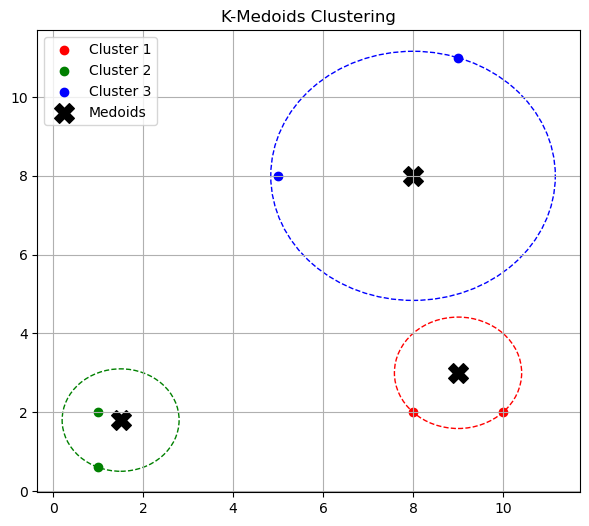

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Sample dataset
X = np.array([
    [1,2], [1.5,1.8], [5,8], [8,8],
    [1,0.6], [9,11], [8,2], [10,2], [9,3]
])

# Number of clusters
k = 3

# Maximum number of iterations
max_iter = 100

# Randomly choose initial medoids
medoid_indices = np.random.choice(len(X), k, replace=False)
medoids = X[medoid_indices]

# Run K-Medoids algorithm
for _ in range(max_iter):

    clusters = [[] for _ in range(k)]

    # Assign each point to the closest medoid
    for point in X:
        distances = np.linalg.norm(point - medoids, axis=1)
        cluster_index = np.argmin(distances)
        clusters[cluster_index].append(point)

    new_medoids = []

    # Update medoids
    for i, cluster in enumerate(clusters):

        cluster = np.array(cluster)

        if len(cluster) == 0:
            new_medoids.append(medoids[i])
            continue

        # Compute total distance from each point to all other points
        distance_sums = np.sum(
            [np.linalg.norm(cluster - point, axis=1) for point in cluster],
            axis=1
        )

        # Choose point with minimum total distance
        new_medoids.append(cluster[np.argmin(distance_sums)])

    new_medoids = np.array(new_medoids)

    # Stop if medoids do not change
    if np.allclose(medoids, new_medoids):
        break

    medoids = new_medoids


# Visualization
colors = ['red', 'green', 'blue']

plt.figure(figsize=(7,6))

for i, cluster in enumerate(clusters):

    cluster = np.array(cluster)

    if len(cluster) == 0:
        continue

    # Plot cluster points
    plt.scatter(cluster[:,0], cluster[:,1], c=colors[i], label=f"Cluster {i+1}")

    # Draw circle around cluster
    medoid = medoids[i]
    radius = np.max(np.linalg.norm(cluster - medoid, axis=1))

    circle = plt.Circle(medoid, radius, color=colors[i], fill=False, linestyle="--")
    plt.gca().add_patch(circle)

# Plot medoids
plt.scatter(medoids[:,0], medoids[:,1],
            c='black', marker='X', s=200, label="Medoids")

plt.title("K-Medoids Clustering")
plt.legend()
plt.grid(True)
plt.show()